## Problem 6: Predicting U.S. Recession Probability Using the Yield Curve

**Importing Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

**Load yield spread data from FRED**

In [4]:
spread_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=T10Y3MM"

spread = pd.read_csv(spread_url)

spread.head()

,observation_date,T10Y3MM
0,1982-01-01,1.67
1,1982-02-01,0.15
2,1982-03-01,0.55
3,1982-04-01,0.53
4,1982-05-01,0.91


**Clean Yield Spread Data**

In [5]:
spread = spread.rename(columns={
    "observation_date": "Date",
    "T10Y3MM": "Yield_Spread"
})

spread["Date"] = pd.to_datetime(spread["Date"])

spread["Yield_Spread"] = pd.to_numeric(
    spread["Yield_Spread"],
    errors="coerce"
)

spread.head()

,Date,Yield_Spread
0,1982-01-01,1.67
1,1982-02-01,0.15
2,1982-03-01,0.55
3,1982-04-01,0.53
4,1982-05-01,0.91


**Load U.S. recession indicator from FRED**

In [6]:
recession_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=USREC"

recession = pd.read_csv(recession_url)

recession.head()

,observation_date,USREC
0,1854-12-01,1
1,1855-01-01,0
2,1855-02-01,0
3,1855-03-01,0
4,1855-04-01,0


**Clean Recession Data**

In [7]:
recession = recession.rename(columns={
    "observation_date": "Date",
    "USREC": "Recession"
})

recession["Date"] = pd.to_datetime(recession["Date"])

recession["Recession"] = pd.to_numeric(
    recession["Recession"],
    errors="coerce"
)

recession.head()

,Date,Recession
0,1854-12-01,1
1,1855-01-01,0
2,1855-02-01,0
3,1855-03-01,0
4,1855-04-01,0


Recession = 1 means the U.S. economy is in recession

Recession = 0 means the U.S. economy is not in recession

**Merge Datasets**

In [8]:
data = pd.merge(
    spread,
    recession,
    on="Date",
    how="inner"
)

data.head()

,Date,Yield_Spread,Recession
0,1982-01-01,1.67,1
1,1982-02-01,0.15,1
2,1982-03-01,0.55,1
3,1982-04-01,0.53,1
4,1982-05-01,0.91,1


In [9]:
data.shape

(534, 3)

**Create the 12-month-ahead recession target**

In [10]:
future_recession_columns = []

for i in range(1, 13):
    future_recession_columns.append(data["Recession"].shift(-i))

future_recession_table = pd.concat(
    future_recession_columns,
    axis=1
)

data["Recession_Next_12M"] = future_recession_table.max(axis=1)

data[["Date", "Yield_Spread", "Recession", "Recession_Next_12M"]].head(15)

,Date,Yield_Spread,Recession,Recession_Next_12M
0,1982-01-01,1.67,1,1.0
1,1982-02-01,0.15,1,1.0
2,1982-03-01,0.55,1,1.0
3,1982-04-01,0.53,1,1.0
4,1982-05-01,0.91,1,1.0
5,1982-06-01,1.22,1,1.0
6,1982-07-01,2.09,1,1.0
7,1982-08-01,4.06,1,1.0
8,1982-09-01,4.15,1,1.0
9,1982-10-01,2.94,1,1.0


**Drop missing rows**

In [11]:
data = data.dropna(
    subset=[
        "Yield_Spread",
        "Recession_Next_12M"
    ]
).copy()

data["Recession_Next_12M"] = data["Recession_Next_12M"].astype(int)

data.shape

(533, 4)

In [12]:
data["Recession_Next_12M"].value_counts()

Recession_Next_12M
0    443
1     90
Name: count, dtype: int64

**Plot the Yield Spreads**

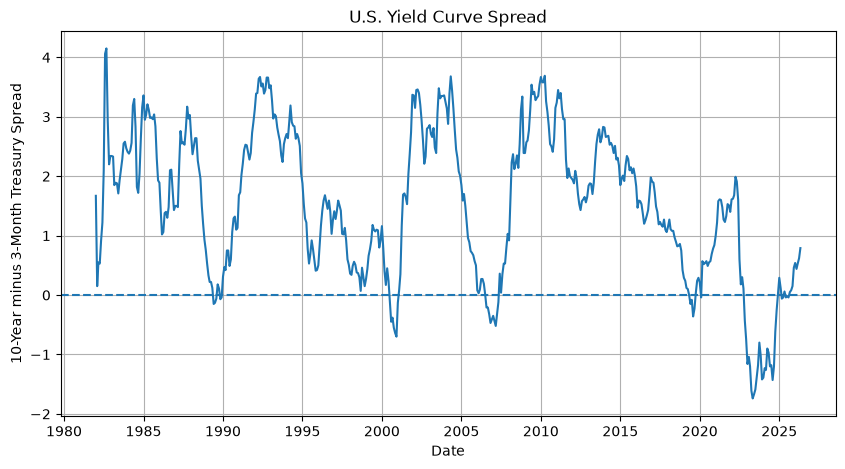

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(data["Date"], data["Yield_Spread"])

plt.axhline(0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("10-Year minus 3-Month Treasury Spread")
plt.title("U.S. Yield Curve Spread")
plt.grid(True)

plt.show()

**Plot yield spread with recession periods**

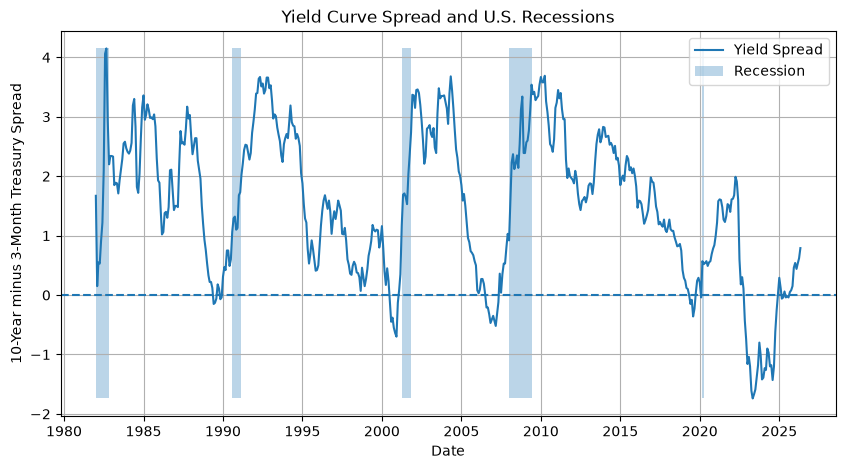

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(data["Date"], data["Yield_Spread"], label="Yield Spread")

plt.fill_between(
    data["Date"],
    data["Yield_Spread"].min(),
    data["Yield_Spread"].max(),
    where=data["Recession"] == 1,
    alpha=0.3,
    label="Recession"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("10-Year minus 3-Month Treasury Spread")
plt.title("Yield Curve Spread and U.S. Recessions")
plt.legend()
plt.grid(True)

plt.show()

This plot helps us visually check whether recessions tend to occur after yield-curve flattening or inversion.

**Create train and test data**

In [15]:
train = data[data["Date"] < "2005-01-01"].copy()
test = data[data["Date"] >= "2005-01-01"].copy()

train.shape, test.shape

((276, 4), (257, 4))

In [16]:
X_train = train[["Yield_Spread"]]
y_train = train["Recession_Next_12M"]

X_test = test[["Yield_Spread"]]
y_test = test["Recession_Next_12M"]

In [17]:
logit_model = LogisticRegression()

logit_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [18]:
y_pred_prob = logit_model.predict_proba(X_test)[:, 1]

y_pred = logit_model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.7392996108949417

In [20]:
confusion_matrix(y_test, y_pred)

array([[179,  36],
       [ 31,  11]])

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       215
           1       0.23      0.26      0.25        42

    accuracy                           0.74       257
   macro avg       0.54      0.55      0.54       257
weighted avg       0.75      0.74      0.75       257



In [22]:
auc = roc_auc_score(y_test, y_pred_prob)

auc

0.559579180509413

**Plot: ROC Curve**

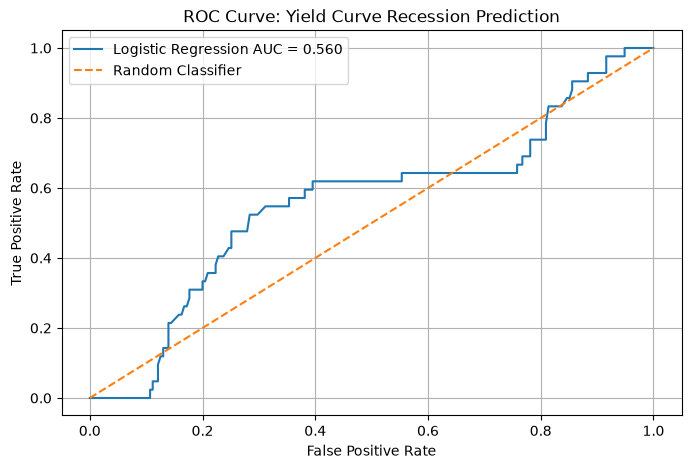

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Yield Curve Recession Prediction")
plt.legend()
plt.grid(True)

plt.show()

**Prediction Table**

In [24]:
predictions = test[
    [
        "Date",
        "Yield_Spread",
        "Recession",
        "Recession_Next_12M"
    ]
].copy()

predictions["Predicted_Recession_Probability"] = y_pred_prob
predictions["Predicted_Class"] = y_pred

predictions.head()

,Date,Yield_Spread,Recession,Recession_Next_12M,Predicted_Recession_Probability,Predicted_Class
276,2005-01-01,1.85,0,0,0.121050,0
277,2005-02-01,1.59,0,0,0.154008,0
278,2005-03-01,1.70,0,0,0.139248,0
279,2005-04-01,1.50,0,0,0.167016,0
280,2005-05-01,1.24,0,0,0.209505,0


**Predicted Recession Probability**

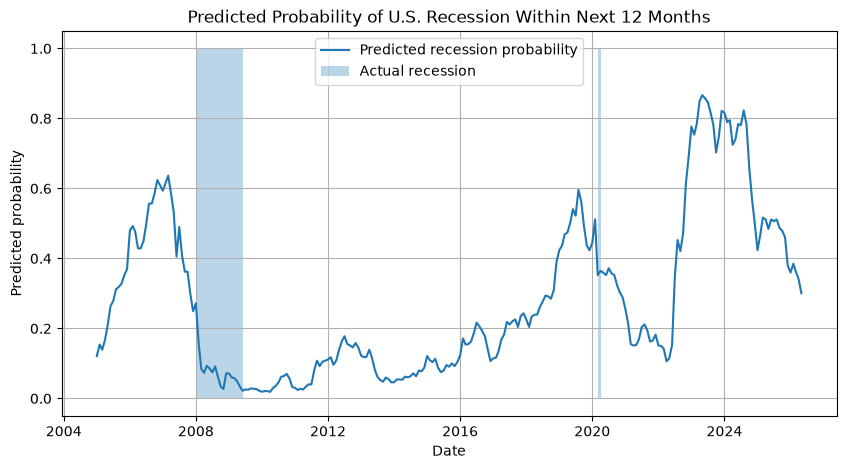

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    predictions["Date"],
    predictions["Predicted_Recession_Probability"],
    label="Predicted recession probability"
)

plt.fill_between(
    predictions["Date"],
    0,
    1,
    where=predictions["Recession"] == 1,
    alpha=0.3,
    label="Actual recession"
)

plt.xlabel("Date")
plt.ylabel("Predicted probability")
plt.title("Predicted Probability of U.S. Recession Within Next 12 Months")
plt.legend()
plt.grid(True)

plt.show()

**Interpret Model Coefficient**

In [26]:
coefficient = logit_model.coef_[0][0]
intercept = logit_model.intercept_[0]

coefficient, intercept

(np.float64(-1.0731393934042024), np.float64(0.0027831183236659302))

**Coefficient Table**

In [27]:
coefficient_table = pd.DataFrame({
    "Variable": ["Intercept", "Yield Spread"],
    "Coefficient": [intercept, coefficient]
})

coefficient_table

,Variable,Coefficient
0,Intercept,0.002783
1,Yield Spread,-1.073139


### Interpretation of Results

The Logistic Regression model was used to predict whether the U.S. economy would experience a recession within the next 12 months using the 10-year minus 3-month Treasury yield spread as the predictor. The estimated coefficient on the yield spread is -1.0731, which has the expected sign. This means that a lower yield spread is associated with a higher predicted probability of recession.

The model achieved an accuracy of 0.7383 on the test set. However, the classification report shows that this accuracy is mainly driven by the model’s ability to identify non-recession periods. For class 0, representing no recession within the next 12 months, the model achieved a recall of 0.83. In contrast, for class 1, representing recession within the next 12 months, the recall was only 0.26. This means that the model identified only 26% of actual recession-risk observations.

The confusion matrix shows that the model correctly identified 178 non-recession observations and 11 recession observations. However, it missed 31 recession observations and incorrectly classified 36 non-recession observations as recession cases. This indicates that the model has limited effectiveness in identifying recession periods using the default classification threshold.

The ROC-AUC score is 0.5596, which is only slightly above random classification. Therefore, although the yield spread has the expected negative relationship with recession probability, the model’s out-of-sample classification performance is weak. This suggests that a single-variable Logistic Regression model may be too simple for reliable recession prediction, especially when recession observations are rare.

Overall, the exercise shows that the yield curve contains useful economic information, but classification performance depends heavily on model specification, threshold choice, and the rarity of recession events.

## Problem 6A

In [28]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [29]:
threshold = 0.50

y_pred_50 = np.where(y_pred_prob >= threshold, 1, 0)

confusion_matrix(y_test, y_pred_50)

array([[179,  36],
       [ 31,  11]])

**Test Multiple Thresholds**

In [30]:
thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:
    
    y_pred_threshold = np.where(y_pred_prob >= threshold, 1, 0)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision_recession = precision_score(
        y_test,
        y_pred_threshold,
        pos_label=1,
        zero_division=0
    )
    recall_recession = recall_score(
        y_test,
        y_pred_threshold,
        pos_label=1
    )
    f1_recession = f1_score(
        y_test,
        y_pred_threshold,
        pos_label=1
    )
    
    results.append({
        "Threshold": threshold,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Accuracy": accuracy,
        "Precision Recession": precision_recession,
        "Recall Recession": recall_recession,
        "F1 Recession": f1_recession
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision Recession,Recall Recession,F1 Recession
0,0.05,25,190,4,38,0.245136,0.166667,0.904762,0.281481
1,0.10,54,161,15,27,0.315175,0.143617,0.642857,0.234783
2,0.15,86,129,15,27,0.439689,0.173077,0.642857,0.272727
3,0.20,112,103,16,26,0.536965,0.201550,0.619048,0.304094
4,0.25,130,85,17,25,0.603113,0.227273,0.595238,0.328947
5,0.30,139,76,19,23,0.630350,0.232323,0.547619,0.326241
6,0.35,148,67,19,23,0.665370,0.255556,0.547619,0.348485
7,0.40,161,54,22,20,0.704280,0.270270,0.476190,0.344828
8,0.45,168,47,27,15,0.712062,0.241935,0.357143,0.288462
9,0.50,179,36,31,11,0.739300,0.234043,0.261905,0.247191


**Add Cost Sensitive Evaluation**

In [31]:
false_positive_cost = 1
false_negative_cost = 5

threshold_results["Total Cost"] = (
    threshold_results["False Positives"] * false_positive_cost
    + threshold_results["False Negatives"] * false_negative_cost
)

threshold_results

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision Recession,Recall Recession,F1 Recession,Total Cost
0,0.05,25,190,4,38,0.245136,0.166667,0.904762,0.281481,210
1,0.10,54,161,15,27,0.315175,0.143617,0.642857,0.234783,236
2,0.15,86,129,15,27,0.439689,0.173077,0.642857,0.272727,204
3,0.20,112,103,16,26,0.536965,0.201550,0.619048,0.304094,183
4,0.25,130,85,17,25,0.603113,0.227273,0.595238,0.328947,170
5,0.30,139,76,19,23,0.630350,0.232323,0.547619,0.326241,171
6,0.35,148,67,19,23,0.665370,0.255556,0.547619,0.348485,162
7,0.40,161,54,22,20,0.704280,0.270270,0.476190,0.344828,164
8,0.45,168,47,27,15,0.712062,0.241935,0.357143,0.288462,182
9,0.50,179,36,31,11,0.739300,0.234043,0.261905,0.247191,191


**Find the lowest-cost threshold**

In [32]:
best_cost_threshold = threshold_results.loc[
    threshold_results["Total Cost"].idxmin()
]

best_cost_threshold

Threshold                0.350000
True Negatives         148.000000
False Positives         67.000000
False Negatives         19.000000
True Positives          23.000000
Accuracy                 0.665370
Precision Recession      0.255556
Recall Recession         0.547619
F1 Recession             0.348485
Total Cost             162.000000
Name: 6, dtype: float64

**Find the threshold with best recession F1-score**

In [33]:
best_f1_threshold = threshold_results.loc[
    threshold_results["F1 Recession"].idxmax()
]

best_f1_threshold

Threshold                0.350000
True Negatives         148.000000
False Positives         67.000000
False Negatives         19.000000
True Positives          23.000000
Accuracy                 0.665370
Precision Recession      0.255556
Recall Recession         0.547619
F1 Recession             0.348485
Total Cost             162.000000
Name: 6, dtype: float64

**Compare threshold 0.50 with best-cost threshold**

In [34]:
threshold_50_row = threshold_results[
    np.isclose(threshold_results["Threshold"], 0.50)
]

comparison_thresholds = pd.concat(
    [
        threshold_50_row,
        best_cost_threshold.to_frame().T
    ],
    axis=0
)

comparison_thresholds

,Threshold,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision Recession,Recall Recession,F1 Recession,Total Cost
9,0.50,179.0,36.0,31.0,11.0,0.73930,0.234043,0.261905,0.247191,191.0
6,0.35,148.0,67.0,19.0,23.0,0.66537,0.255556,0.547619,0.348485,162.0


**Plot: Threshold v. Recession Recall**

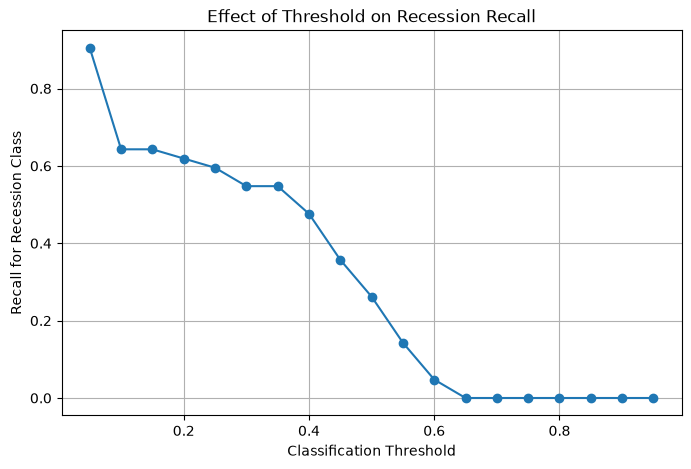

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall Recession"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Recall for Recession Class")
plt.title("Effect of Threshold on Recession Recall")
plt.grid(True)

plt.show()

**Plot: Threshold v. Total Cost**

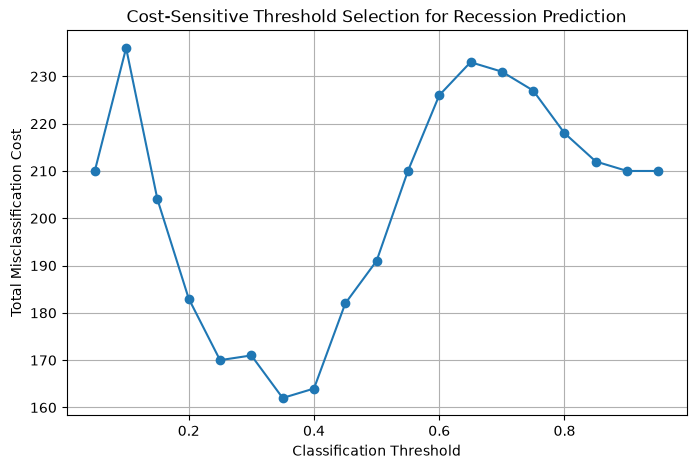

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Total Cost"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Total Misclassification Cost")
plt.title("Cost-Sensitive Threshold Selection for Recession Prediction")
plt.grid(True)

plt.show()

**Plot: Precision & Recall together**

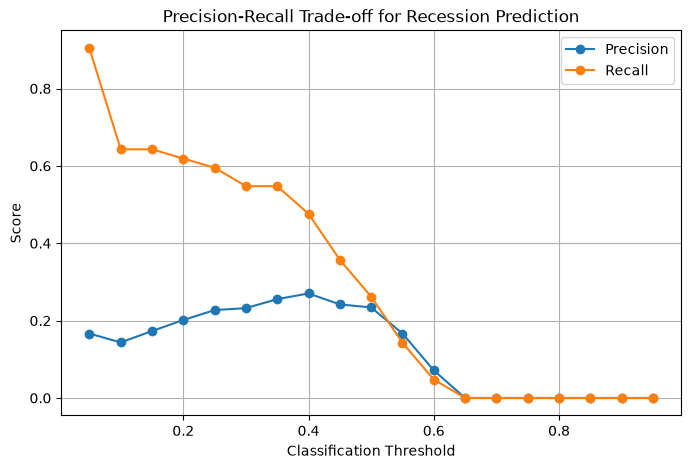

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision Recession"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall Recession"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off for Recession Prediction")
plt.legend()
plt.grid(True)

plt.show()

## END